In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import altair as als
import seaborn as sns
import folium

In [2]:
sampled_data = pd.read_csv('BankChurners.csv')

In [3]:
sampled_data

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


# El conjunto de datos "BankChurners.csv" contiene las siguientes variables:
1. CLIENTNUM: Número de identificación del cliente.
2. Attrition_Flag: Indica si el cliente dejó de ser cliente del banco (attrition) o sigue siendo cliente.
3. Customer_Age: Edad del cliente.
4. Gender: Género del cliente.
5. Dependent_count: Número de dependientes.
6. Education_Level: Nivel educativo del cliente.
7. Marital_Status: Estado civil del cliente.
8. Income_Category: Categoría de ingresos del cliente.
9. Card_Category: Tipo de tarjeta de crédito (por ejemplo, Blue, Silver, etc.).
10. Months_on_book: Cantidad de meses que el cliente ha estado con el banco.
11. Total_Relationship_Count: Número total de productos que el cliente tiene con el banco.
12. Months_Inactive_12_mon: Número de meses que el cliente ha estado inactivo en los últimos 12 meses.
13. Contacts_Count_12_mon: Número de veces que el cliente ha contactado con el banco en los últimos 12 meses.
14. Credit_Limit: Límite de crédito en la tarjeta de crédito.
15. Total_Revolving_Bal: Saldo revolvente total en la tarjeta de crédito.
16. Avg_Open_To_Buy: Línea de crédito disponible promedio en los últimos 12 meses.
17. Total_Amt_Chng_Q4_Q1: Cambio en el monto de las transacciones (Q4 sobre Q1).
18. Total_Trans_Amt: Monto total de las transacciones en los últimos 12 meses.
19. Total_Trans_Ct: Cantidad total de transacciones en los últimos 12 meses.
20. Total_Ct_Chng_Q4_Q1: Cambio en la cantidad de transacciones (Q4 sobre Q1).
21. Avg_Utilization_Ratio: Ratio promedio de utilización de la tarjeta de crédito.
22.  Naive_Bayes_Classifier...: Dos columnas relacionadas con la clasificación de Naive Bayes, probablemente usadas en un modelo predictivo para determinar la probabilidad de que un cliente deje el banco.

# analisis univariado

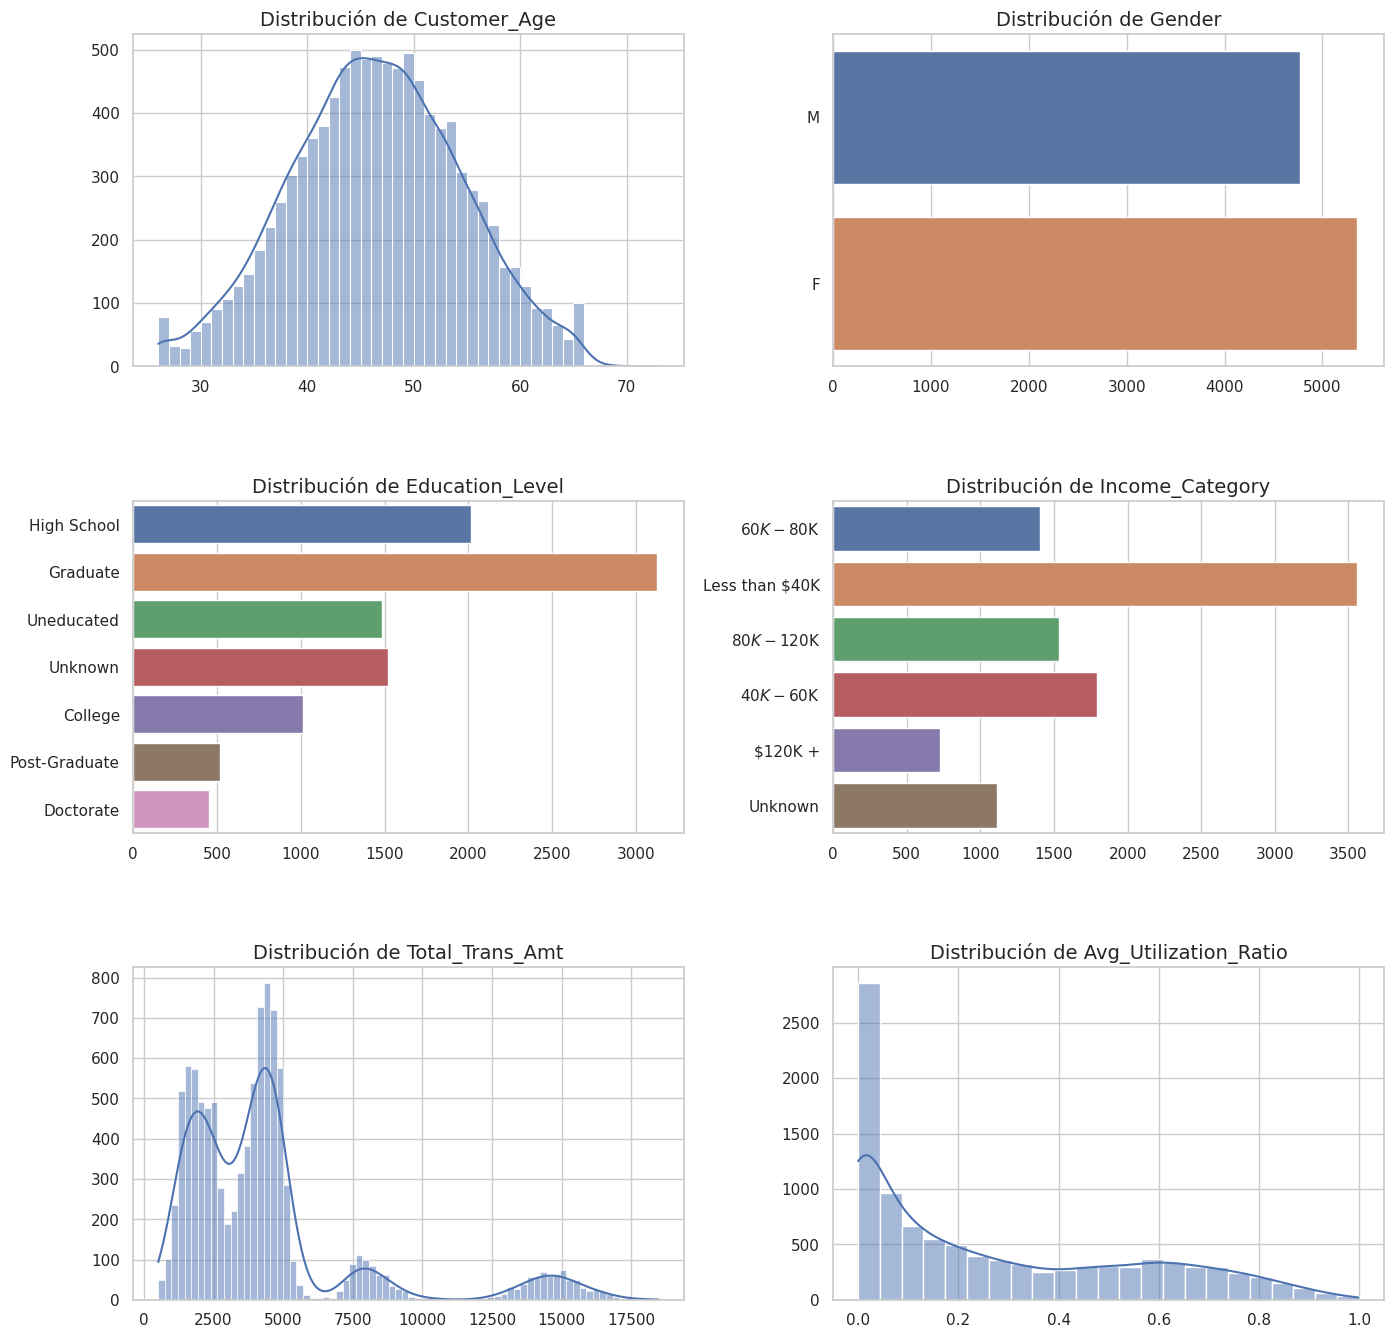

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilos para las visualizaciones
sns.set(style="whitegrid")

# Lista de variables para el análisis univariado
variables_to_analyze = ['Customer_Age', 'Gender', 'Education_Level', 'Income_Category',
                        'Total_Trans_Amt', 'Avg_Utilization_Ratio']

# Creando figuras para las visualizaciones
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

# Ajustando la disposición de los gráficos
plt.tight_layout(pad=6.0)

# Realizando el análisis univariado y las visualizaciones
for i, var in enumerate(variables_to_analyze):
    ax = axes[i//2, i%2]
    if sampled_data[var].dtype == 'object':
        # Para variables categóricas: gráfico de barras
        sns.countplot(y=var, data=sampled_data, ax=ax)
    else:
        # Para variables numéricas: histograma
        sns.histplot(sampled_data[var], kde=True, ax=ax)
    ax.set_title(f'Distribución de {var}', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('')

# Mostrando las visualizaciones
plt.show()

1. Customer_Age: La distribución de la edad de los clientes muestra una forma aproximadamente normal, centrada alrededor de los 40-50 años.

2. Gender: La distribución por género parece bastante equilibrada, con una ligera predominancia de un género sobre el otro.

3. Education_Level: Los niveles educativos están diversificados, con ciertas categorías sobresaliendo más que otras.

4. Income_Category: Las categorías de ingresos de los clientes varían, con algunas categorías siendo más comunes.

5. Total_Trans_Amt: La distribución del monto total de las transacciones tiende a estar sesgada hacia montos menores, lo que indica que la mayoría de los clientes realiza transacciones de menor valor.

6. Avg_Utilization_Ratio: La relación promedio de utilización de la tarjeta de crédito muestra una variedad de patrones, incluyendo una concentración de valores alrededor de cero y otros picos a lo largo de la distribución.

# Analisis bivariado

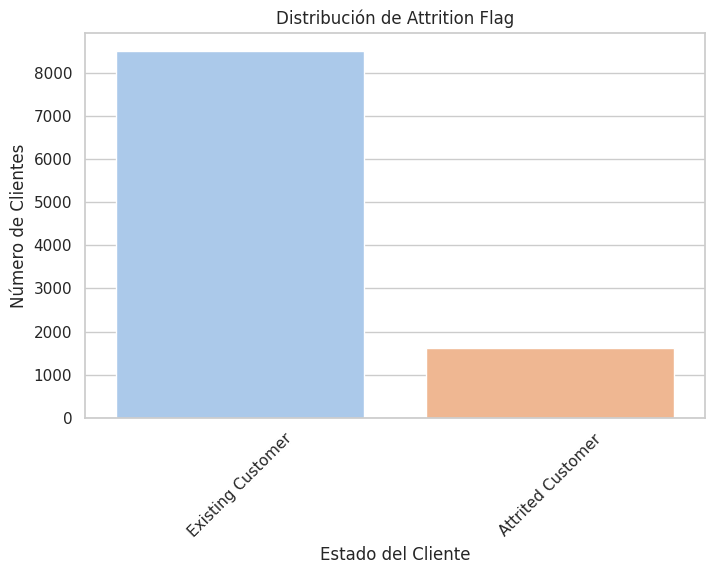

Existing Customer    8500
Attrited Customer    1627
Name: Attrition_Flag, dtype: int64

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de los gráficos
sns.set(style="whitegrid")

# Distribución de la variable Attrition_Flag
attrition_counts = sampled_data['Attrition_Flag'].value_counts()

# Gráfico para la distribución de Attrition_Flag
plt.figure(figsize=(8, 5))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette="pastel")
plt.title('Distribución de Attrition Flag')
plt.ylabel('Número de Clientes')
plt.xlabel('Estado del Cliente')
plt.xticks(rotation=45)
plt.show()

attrition_counts


La distribución de la variable Attrition_Flag muestra que de los 10,127 clientes en el conjunto de datos, 8,500 son clientes existentes ("Existing Customer") y 1,627 son clientes que se han ido ("Attrited Customer"). Esto indica que aproximadamente el 16% de los clientes en este conjunto de datos han abandonado el banco.

<ipython-input-6-c4bbb2a78be6>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(existing_customers[var], label='Existing Customer', shade=True, ax=axes[i])
<ipython-input-6-c4bbb2a78be6>:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(attrited_customers[var], label='Attrited Customer', shade=True, ax=axes[i])
<ipython-input-6-c4bbb2a78be6>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(existing_customers[var], label='Existing Customer', shade=True, ax=axes[i])
<ipython-input-6-c4bbb2a78be6>:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v

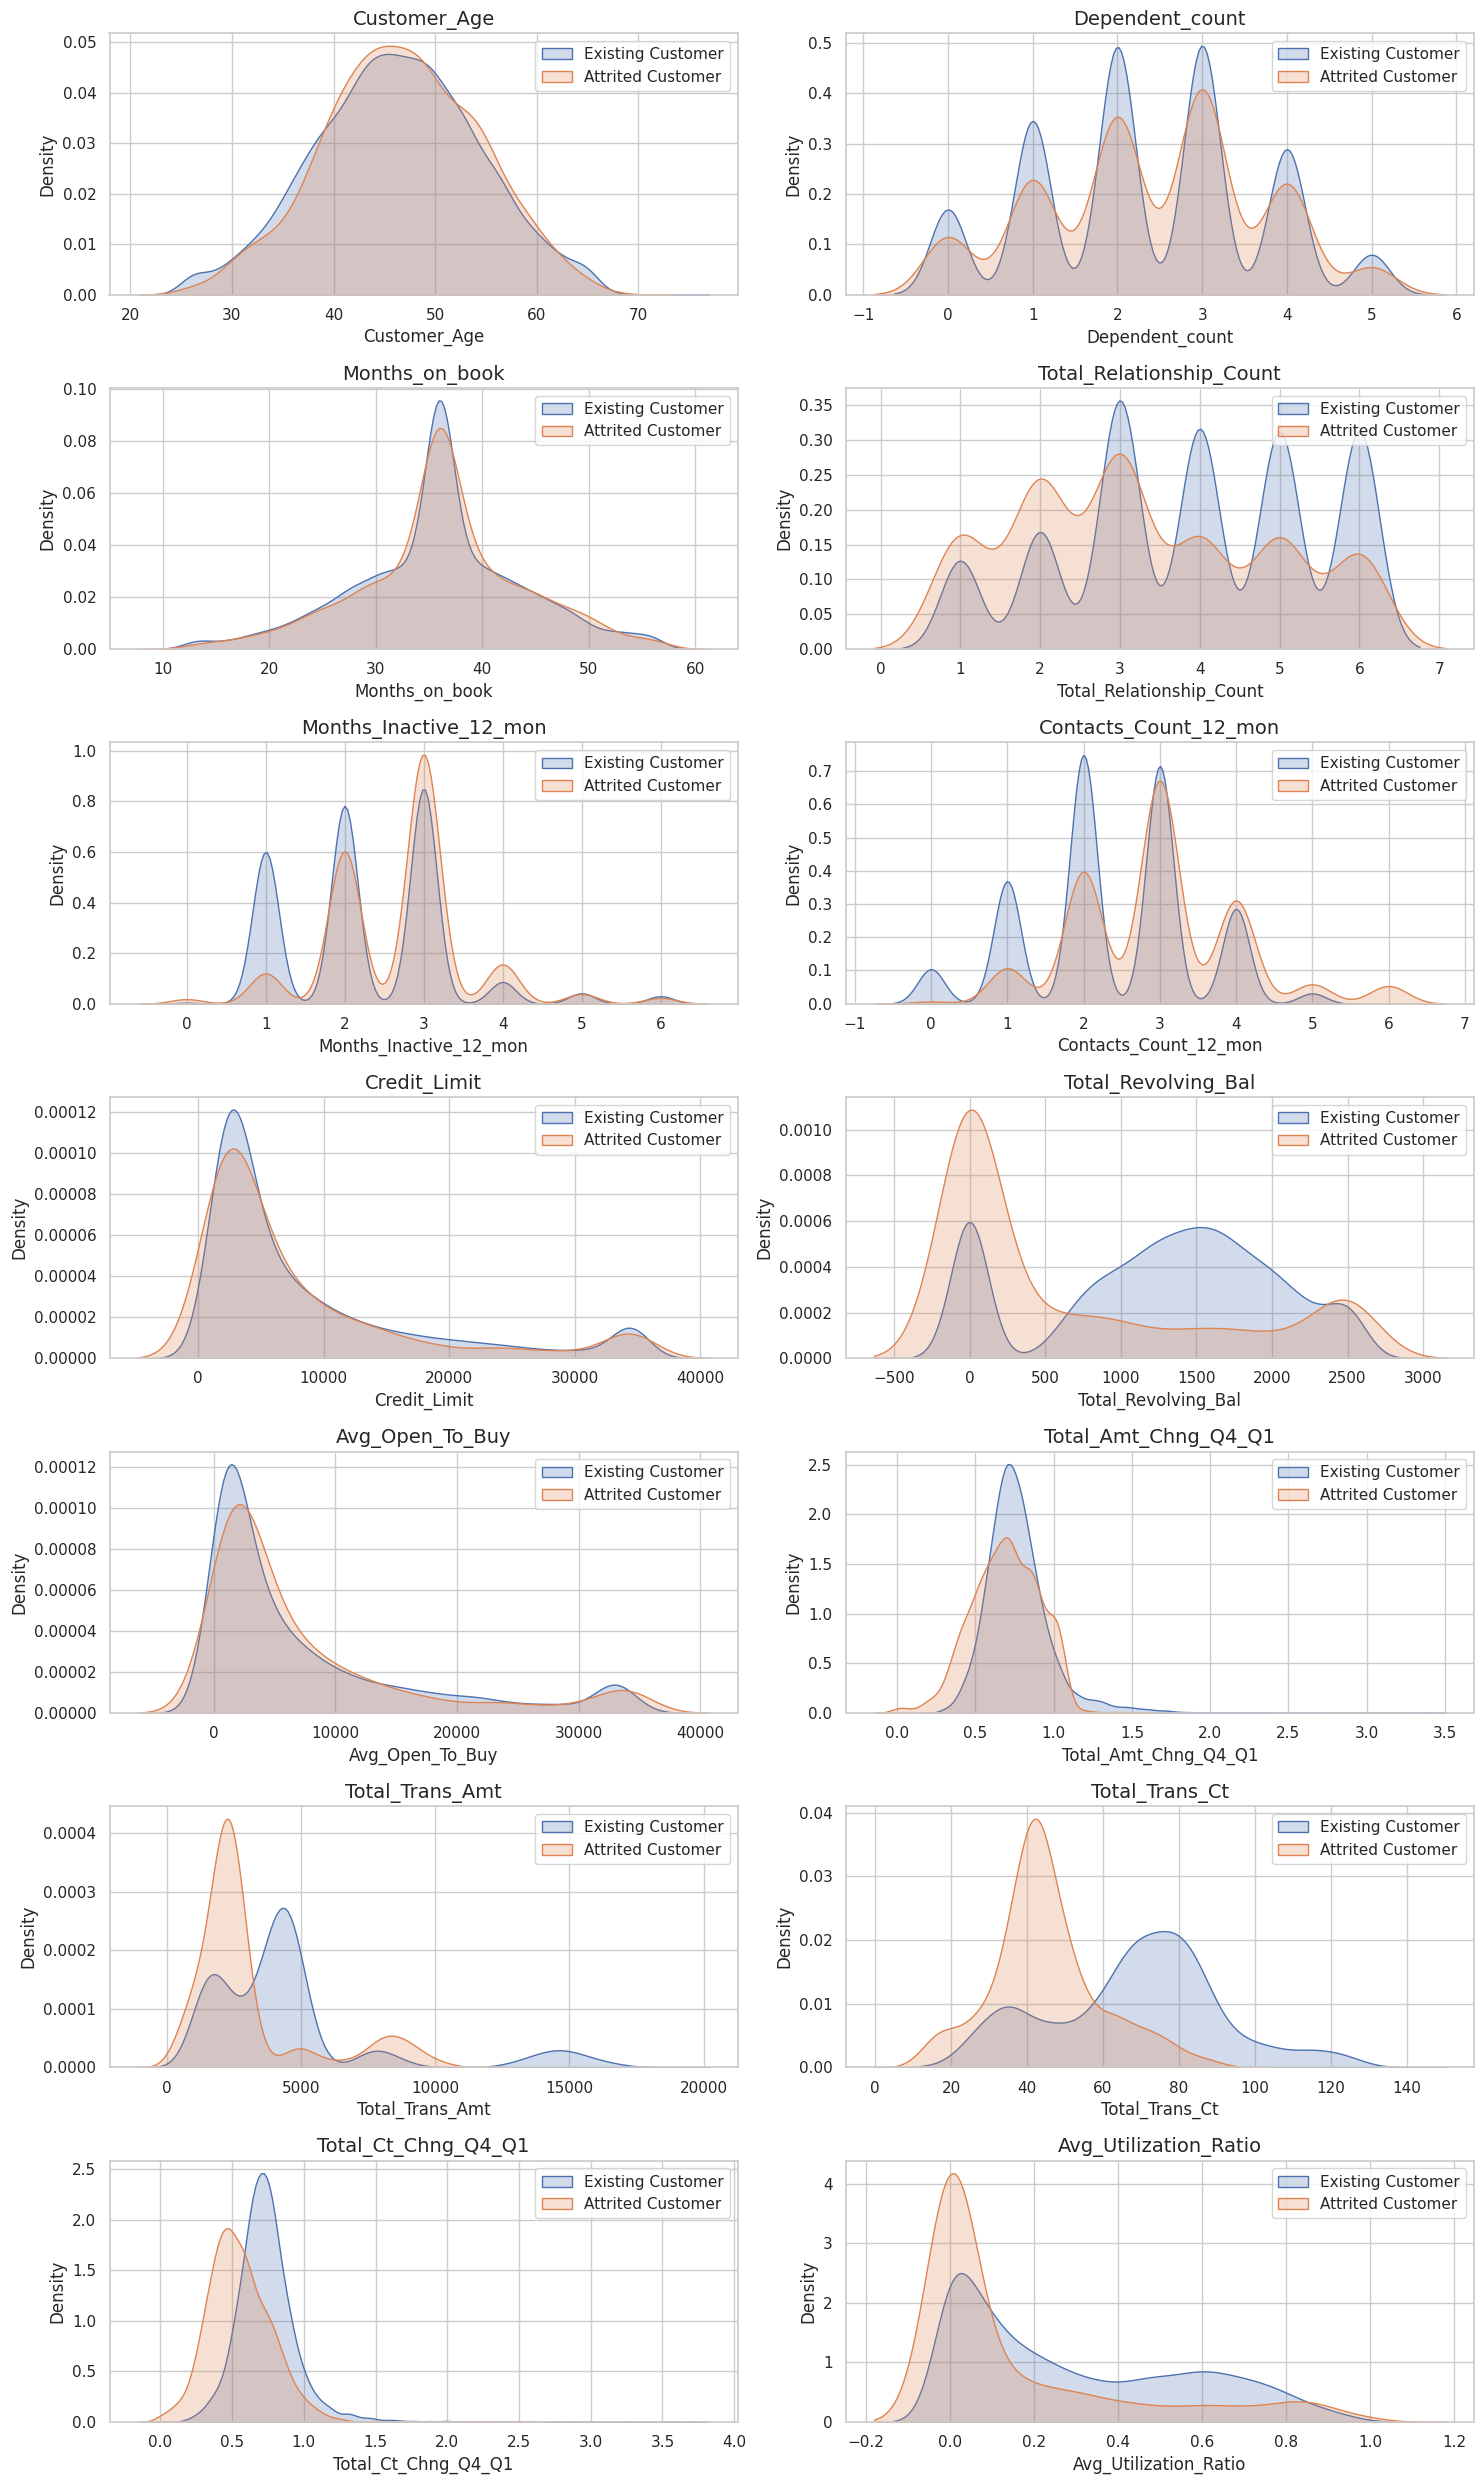

In [6]:

# Separar los datos en dos grupos: clientes existentes y clientes que se han ido
existing_customers = sampled_data[sampled_data['Attrition_Flag'] == 'Existing Customer']
attrited_customers = sampled_data[sampled_data['Attrition_Flag'] == 'Attrited Customer']

# Lista de variables numéricas para comparar
numeric_variables = ['Customer_Age', 'Dependent_count', 'Months_on_book',
                     'Total_Relationship_Count', 'Months_Inactive_12_mon',
                     'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
                     'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
                     'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

# Crear gráficos para cada variable numérica
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(15, 25))
axes = axes.flatten()  # Aplanar la matriz de ejes para la indexación

for i, var in enumerate(numeric_variables):
    sns.kdeplot(existing_customers[var], label='Existing Customer', shade=True, ax=axes[i])
    sns.kdeplot(attrited_customers[var], label='Attrited Customer', shade=True, ax=axes[i])
    axes[i].set_title(var, fontsize=14)
    axes[i].legend()

plt.tight_layout()
plt.show()


1. Customer_Age: Las edades de ambos grupos son bastante similares, lo que sugiere que la edad por sí sola no es un factor distintivo significativo en la deserción de clientes.

2. Dependent_count: La distribución del número de dependientes es similar en ambos grupos.

3. Months_on_book (Meses en el banco): Ambos grupos tienen distribuciones similares, lo que indica que la duración de la relación con el banco no varía mucho entre los clientes que se quedan y los que se van.

4. Total_Relationship_Count: Los clientes que se han ido tienden a tener un menor número de productos con el banco, lo que puede sugerir una menor participación con los servicios del banco.

5. Months_Inactive_12_mon: Hay una diferencia notable aquí; los clientes que se han ido muestran un pico más alto en la inactividad, especialmente alrededor de 2-3 meses de inactividad.

6. Contacts_Count_12_mon: Los clientes que se han ido parecen tener un ligero aumento en el número de contactos con el banco, posiblemente indicando intentos de resolver problemas antes de decidir irse.

7. Credit_Limit y Total_Revolving_Bal: Las diferencias en estas distribuciones no son muy marcadas.

8. Avg_Open_To_Buy: Similar a Credit Limit, no hay una gran diferencia en la distribución entre los dos grupos.

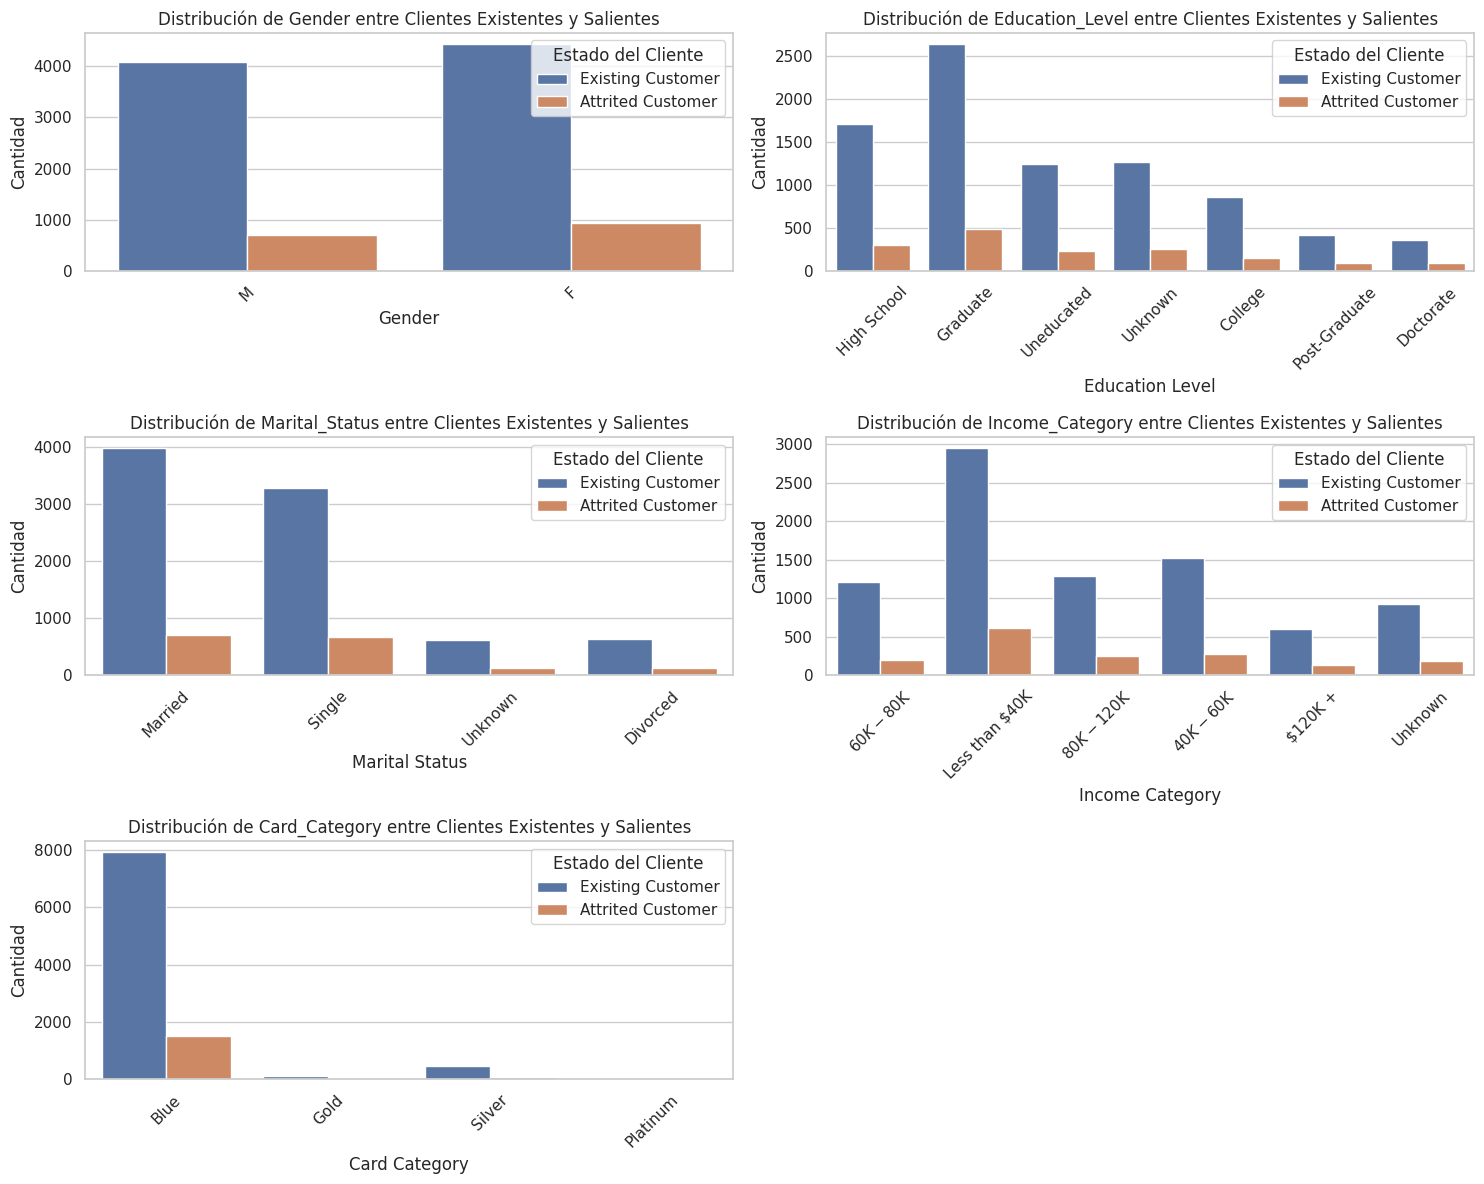

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de los gráficos
sns.set(style="whitegrid")
plt.figure(figsize=(15, 12))

# Lista de variables categóricas a examinar
categorical_vars = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']

# Crear un gráfico de barras para cada variable categórica
for i, var in enumerate(categorical_vars, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=sampled_data, x=var, hue='Attrition_Flag')
    plt.title(f'Distribución de {var} entre Clientes Existentes y Salientes')
    plt.xticks(rotation=45)
    plt.xlabel(var.replace("_", " "))
    plt.ylabel("Cantidad")
    plt.legend(title='Estado del Cliente', loc='upper right')

# Ajustar el layout para evitar la superposición de etiquetas
plt.tight_layout()
plt.show()

1. Género: Ambos géneros muestran una mayor proporción de clientes existentes en comparación con los salientes, aunque la diferencia parece ser ligeramente mayor en los clientes masculinos.

2. Nivel de Educación: Los clientes con diversos niveles de educación tienden a permanecer con el banco, pero hay una notable cantidad de clientes con educación de graduados y con educación secundaria entre los que se van.

3. Estado Civil: Los clientes casados y solteros representan la mayor parte de la base de clientes, tanto en los existentes como en los que se han ido. Los clientes casados parecen tener una proporción ligeramente más alta de fidelidad.

4. Categoría de Ingresos: Los clientes en las categorías de ingresos "Menos de 40K" y "40K - 60K" son predominantes en ambos grupos. La proporción de clientes existentes es mayor en todas las categorías de ingresos.

5. Categoría de la Tarjeta: La mayoría de los clientes, tanto existentes como salientes, tienen tarjetas de la categoría "Blue". Las otras categorías (Silver, Gold, Platinum) tienen un número relativamente pequeño de clientes, pero la proporción de retención parece ser mayor en estas categorías.

# Matriz de correlaciones

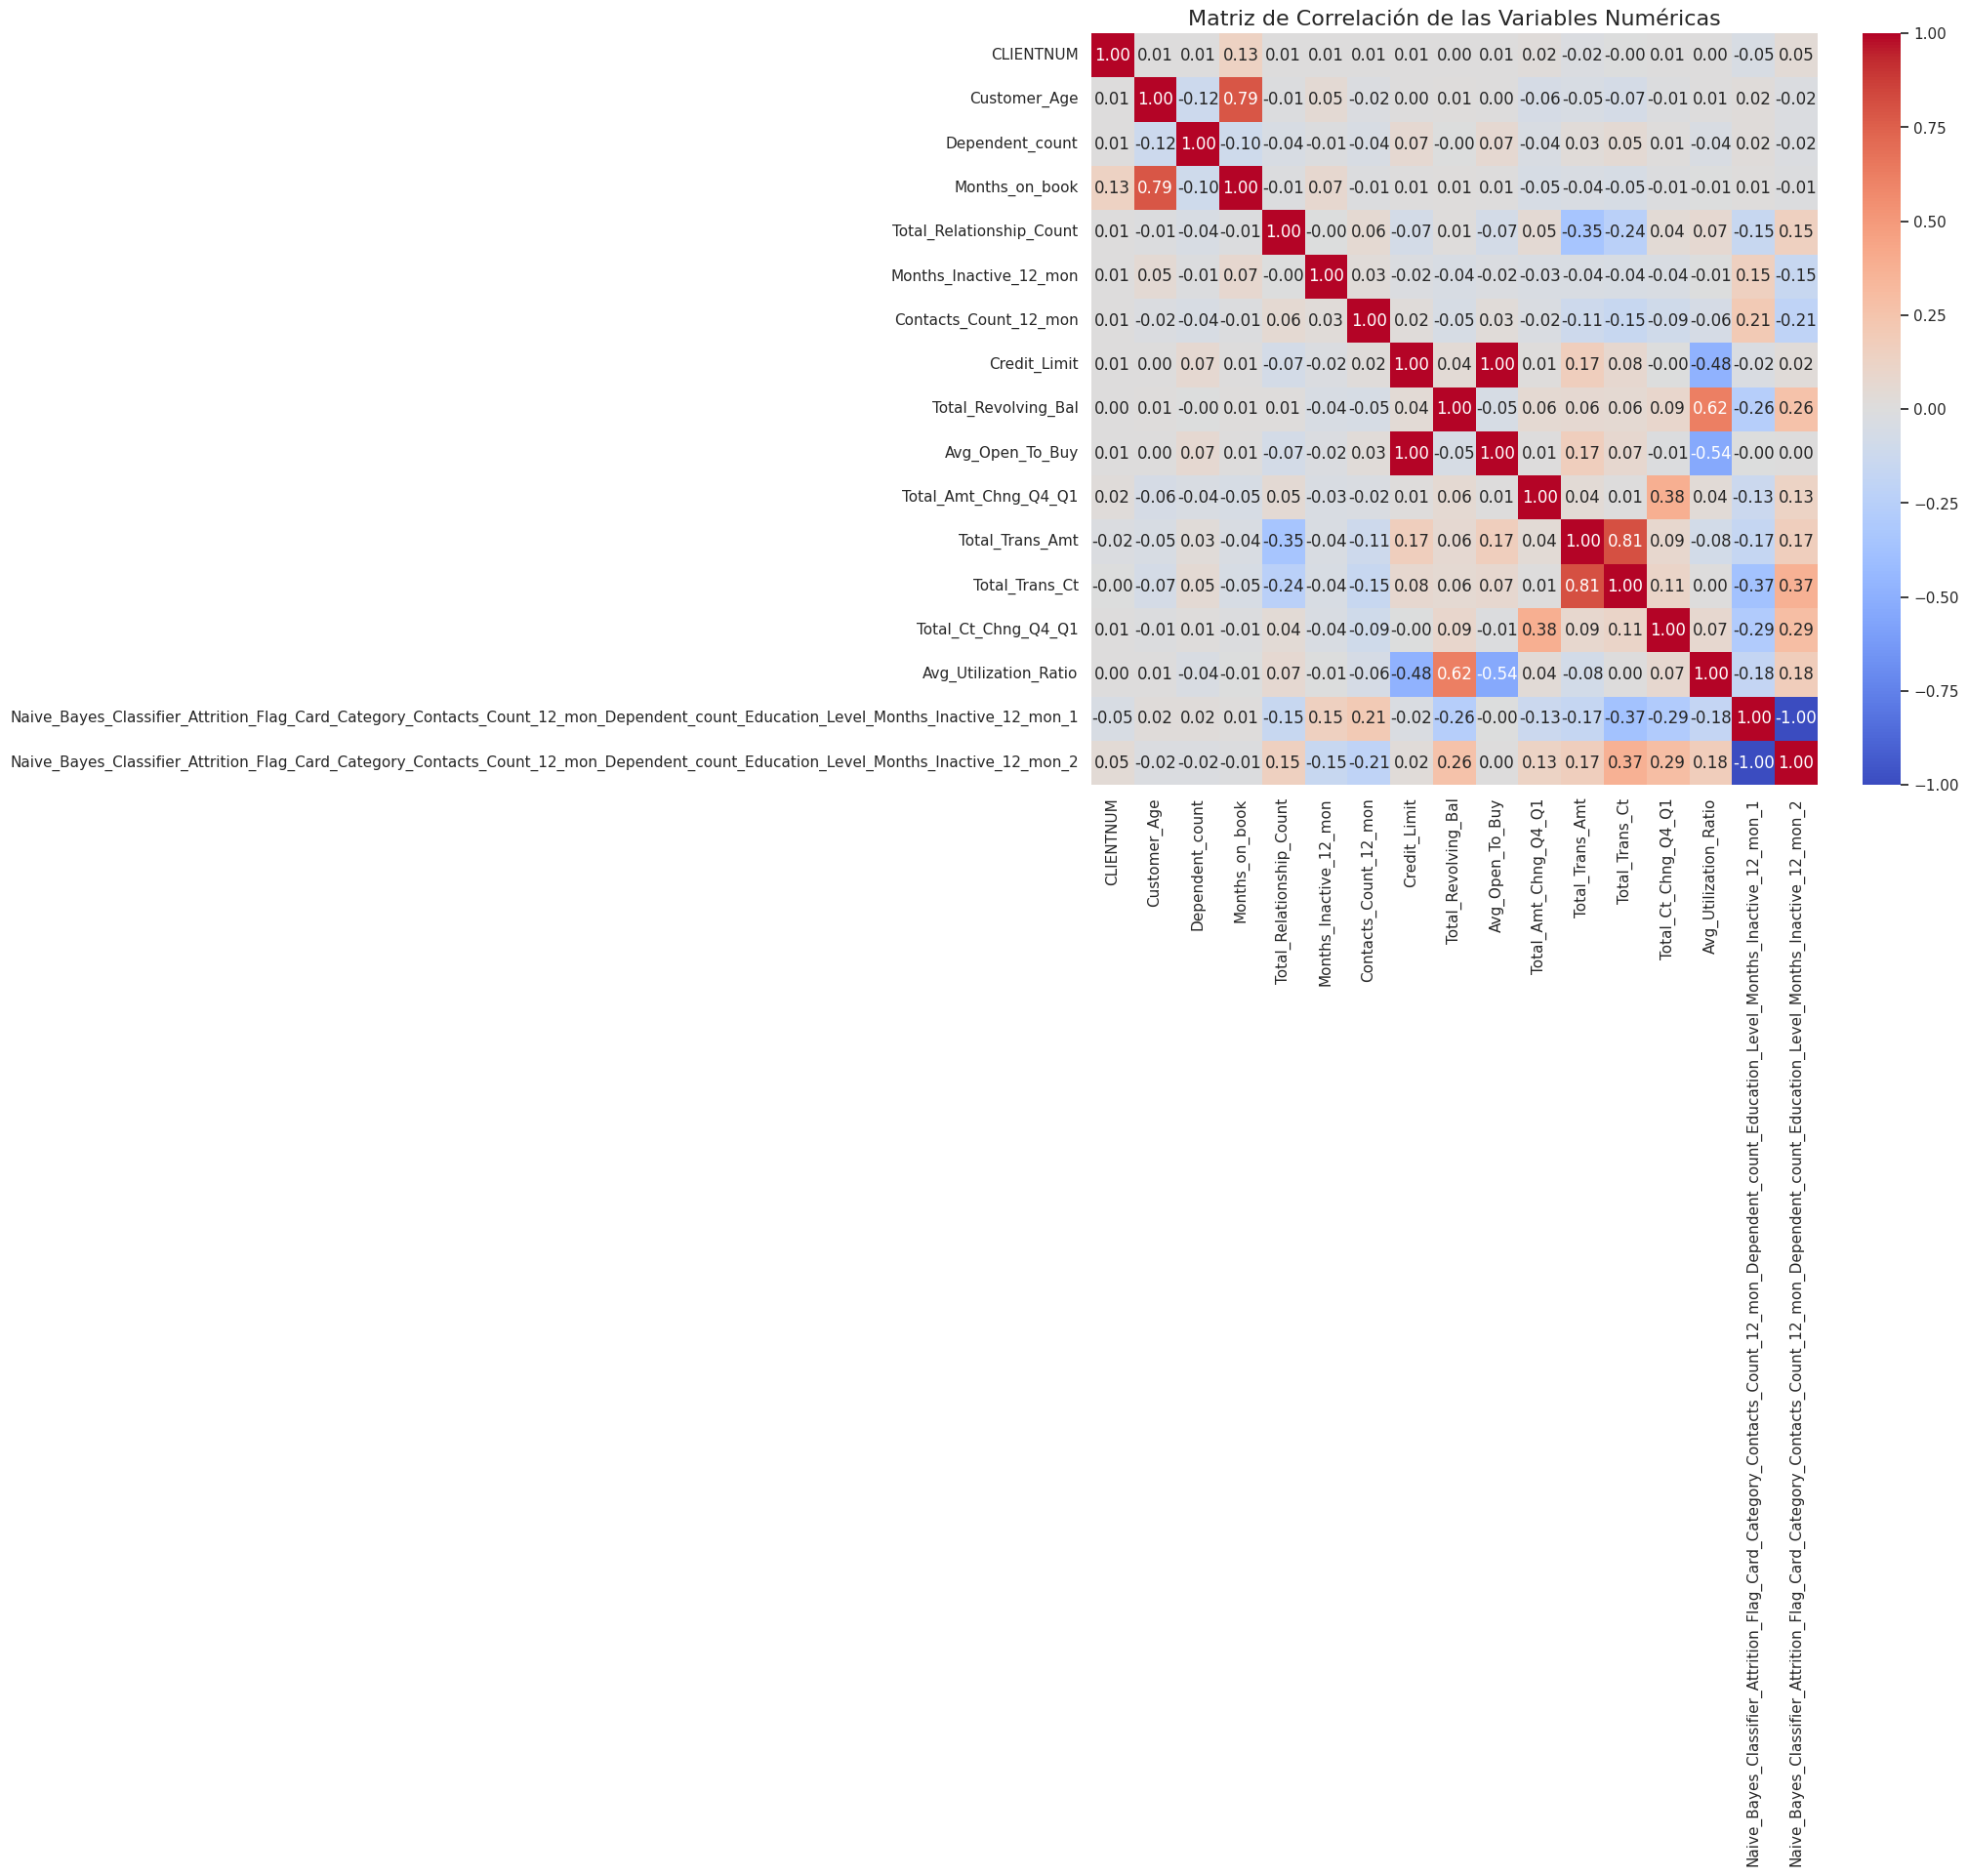

In [ ]:
# Seleccionando solo las variables numéricas para la matriz de correlación
numeric_data = sampled_data.select_dtypes(include=['float64', 'int64'])

# Calculando la matriz de correlación
correlation_matrix = numeric_data.corr()

# Creando una visualización para la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación de las Variables Numéricas", fontsize=16)
plt.show()

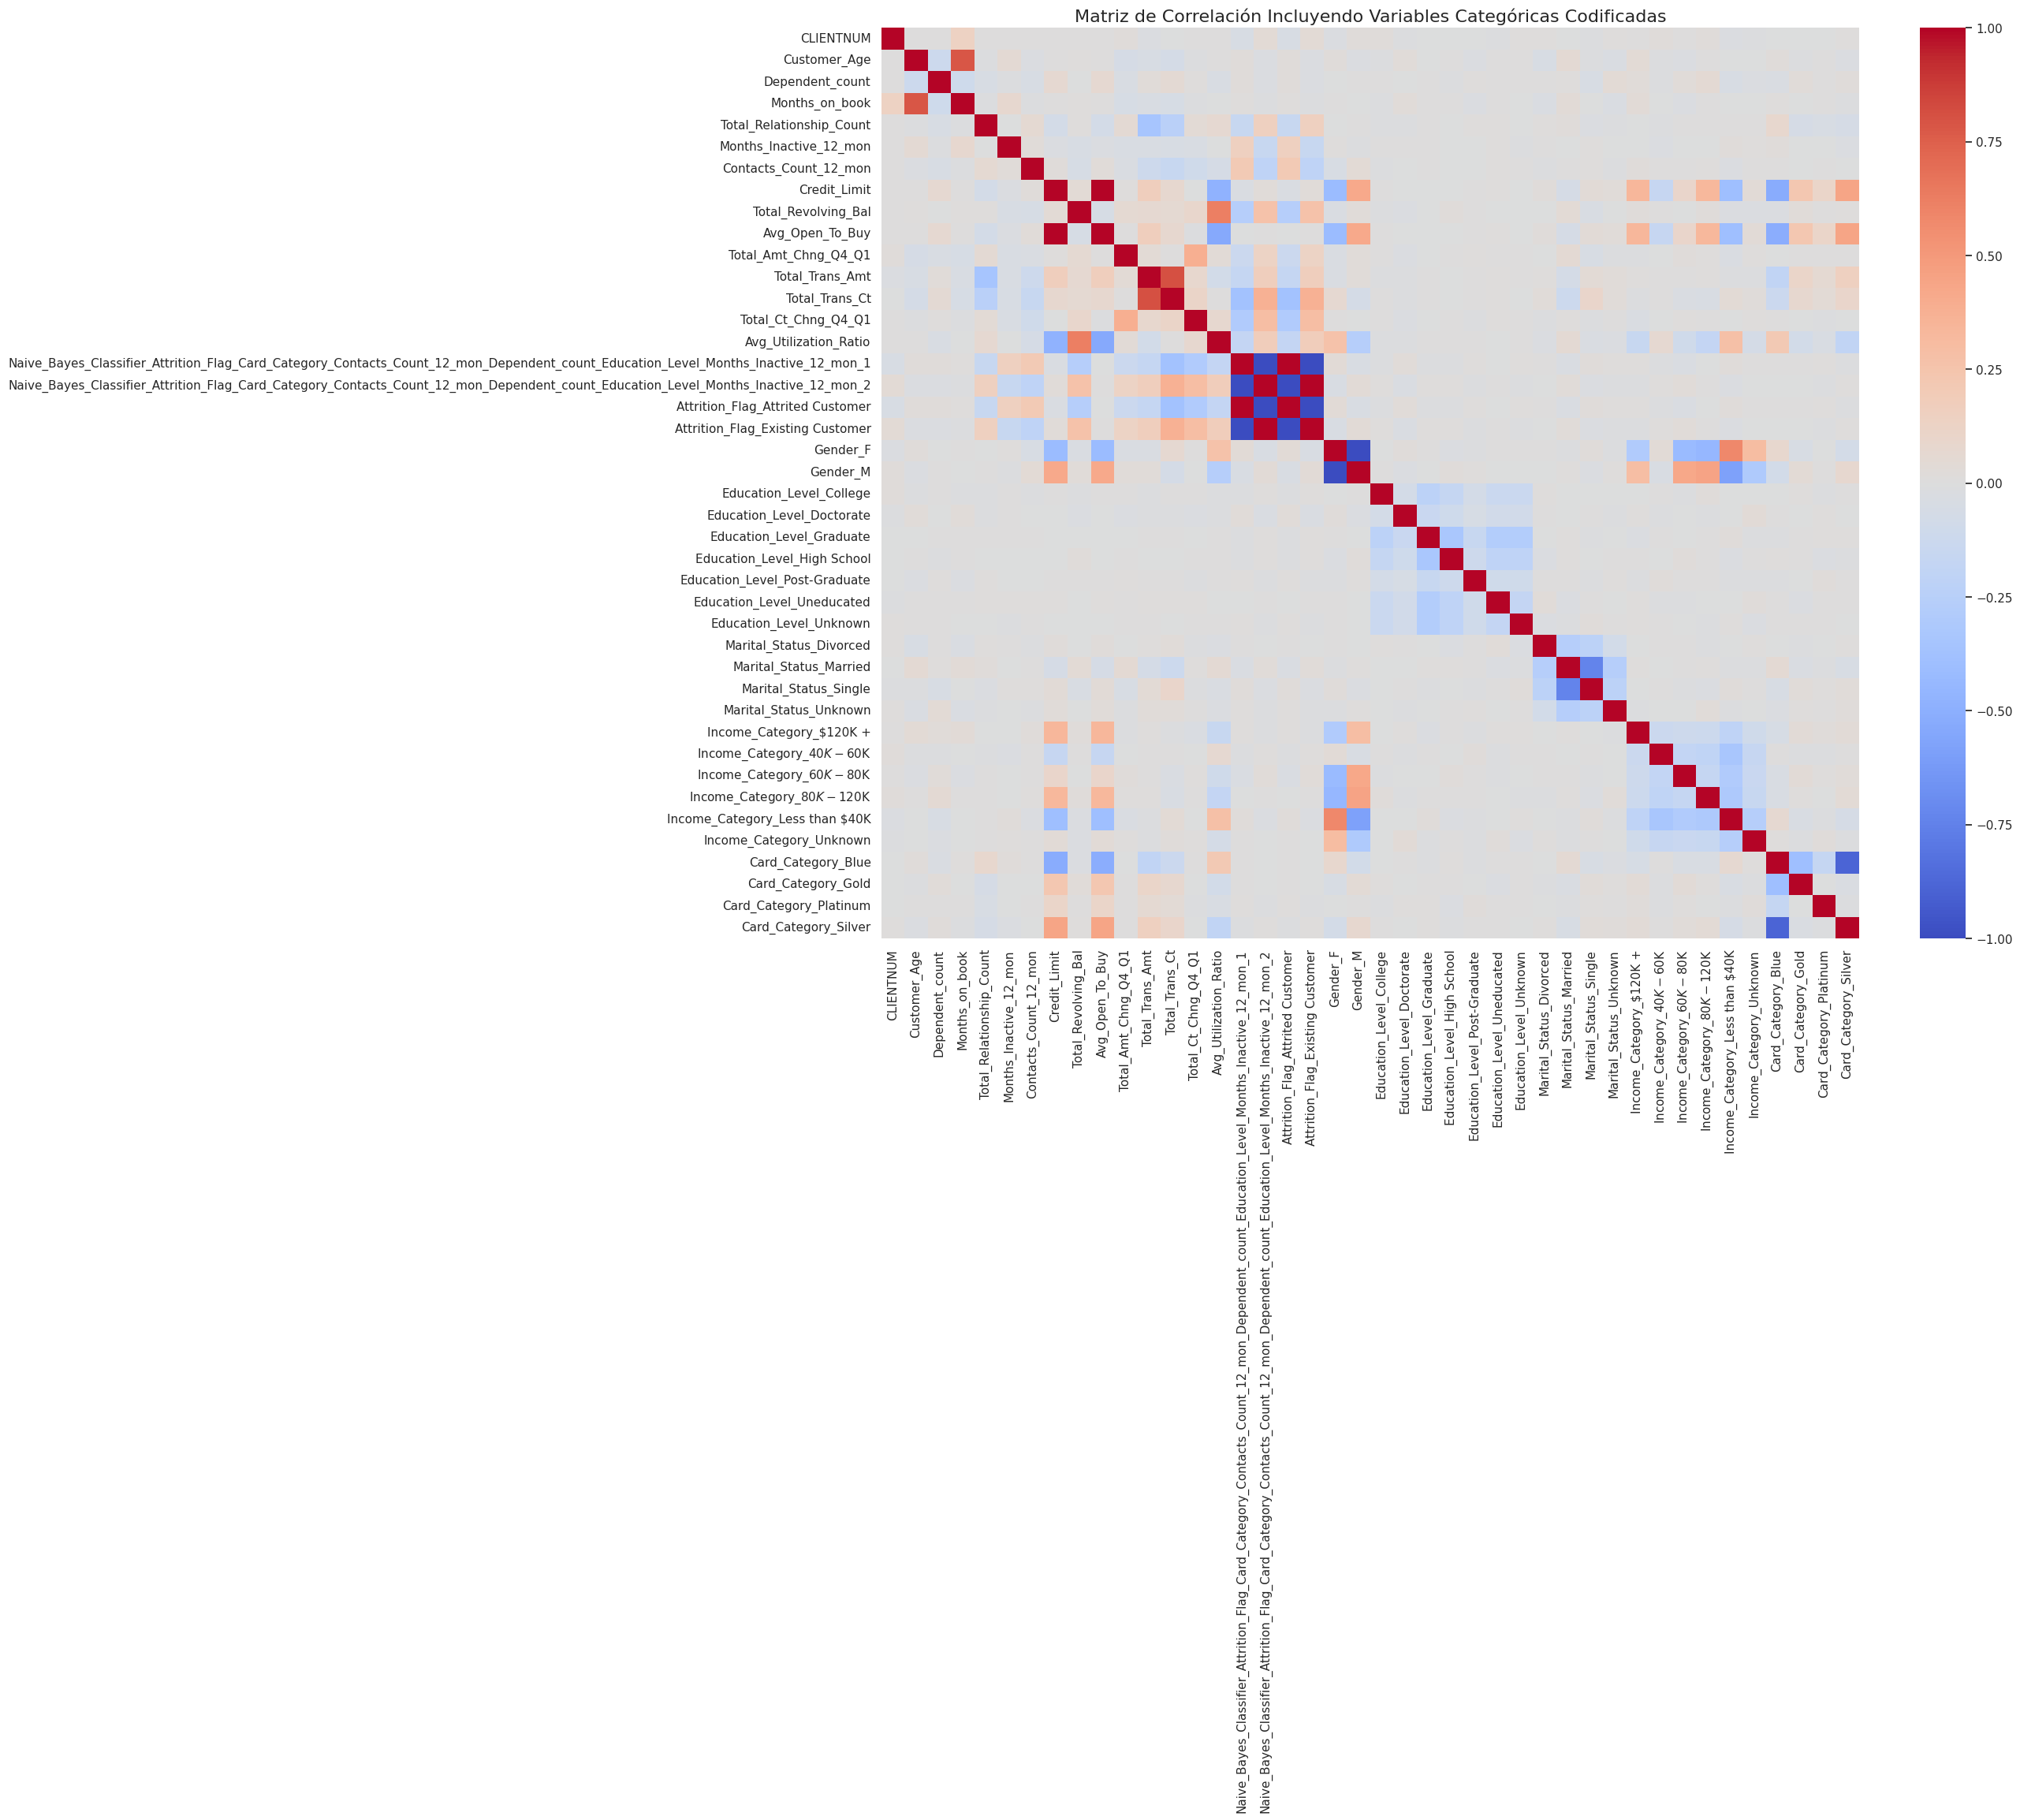

In [ ]:
# Aplicando one-hot encoding a las variables categóricas
categorical_data = pd.get_dummies(sampled_data.select_dtypes(include=['object']))

# Combinando los datos numéricos y categóricos codificados
combined_data = pd.concat([numeric_data, categorical_data], axis=1)

# Calculando la nueva matriz de correlación con las variables categóricas incluidas
combined_correlation_matrix = combined_data.corr()

# Creando una visualización para la nueva matriz de correlación
plt.figure(figsize=(20, 15))
sns.heatmap(combined_correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Matriz de Correlación Incluyendo Variables Categóricas Codificadas", fontsize=16)
plt.show()


# Analisis predictivo

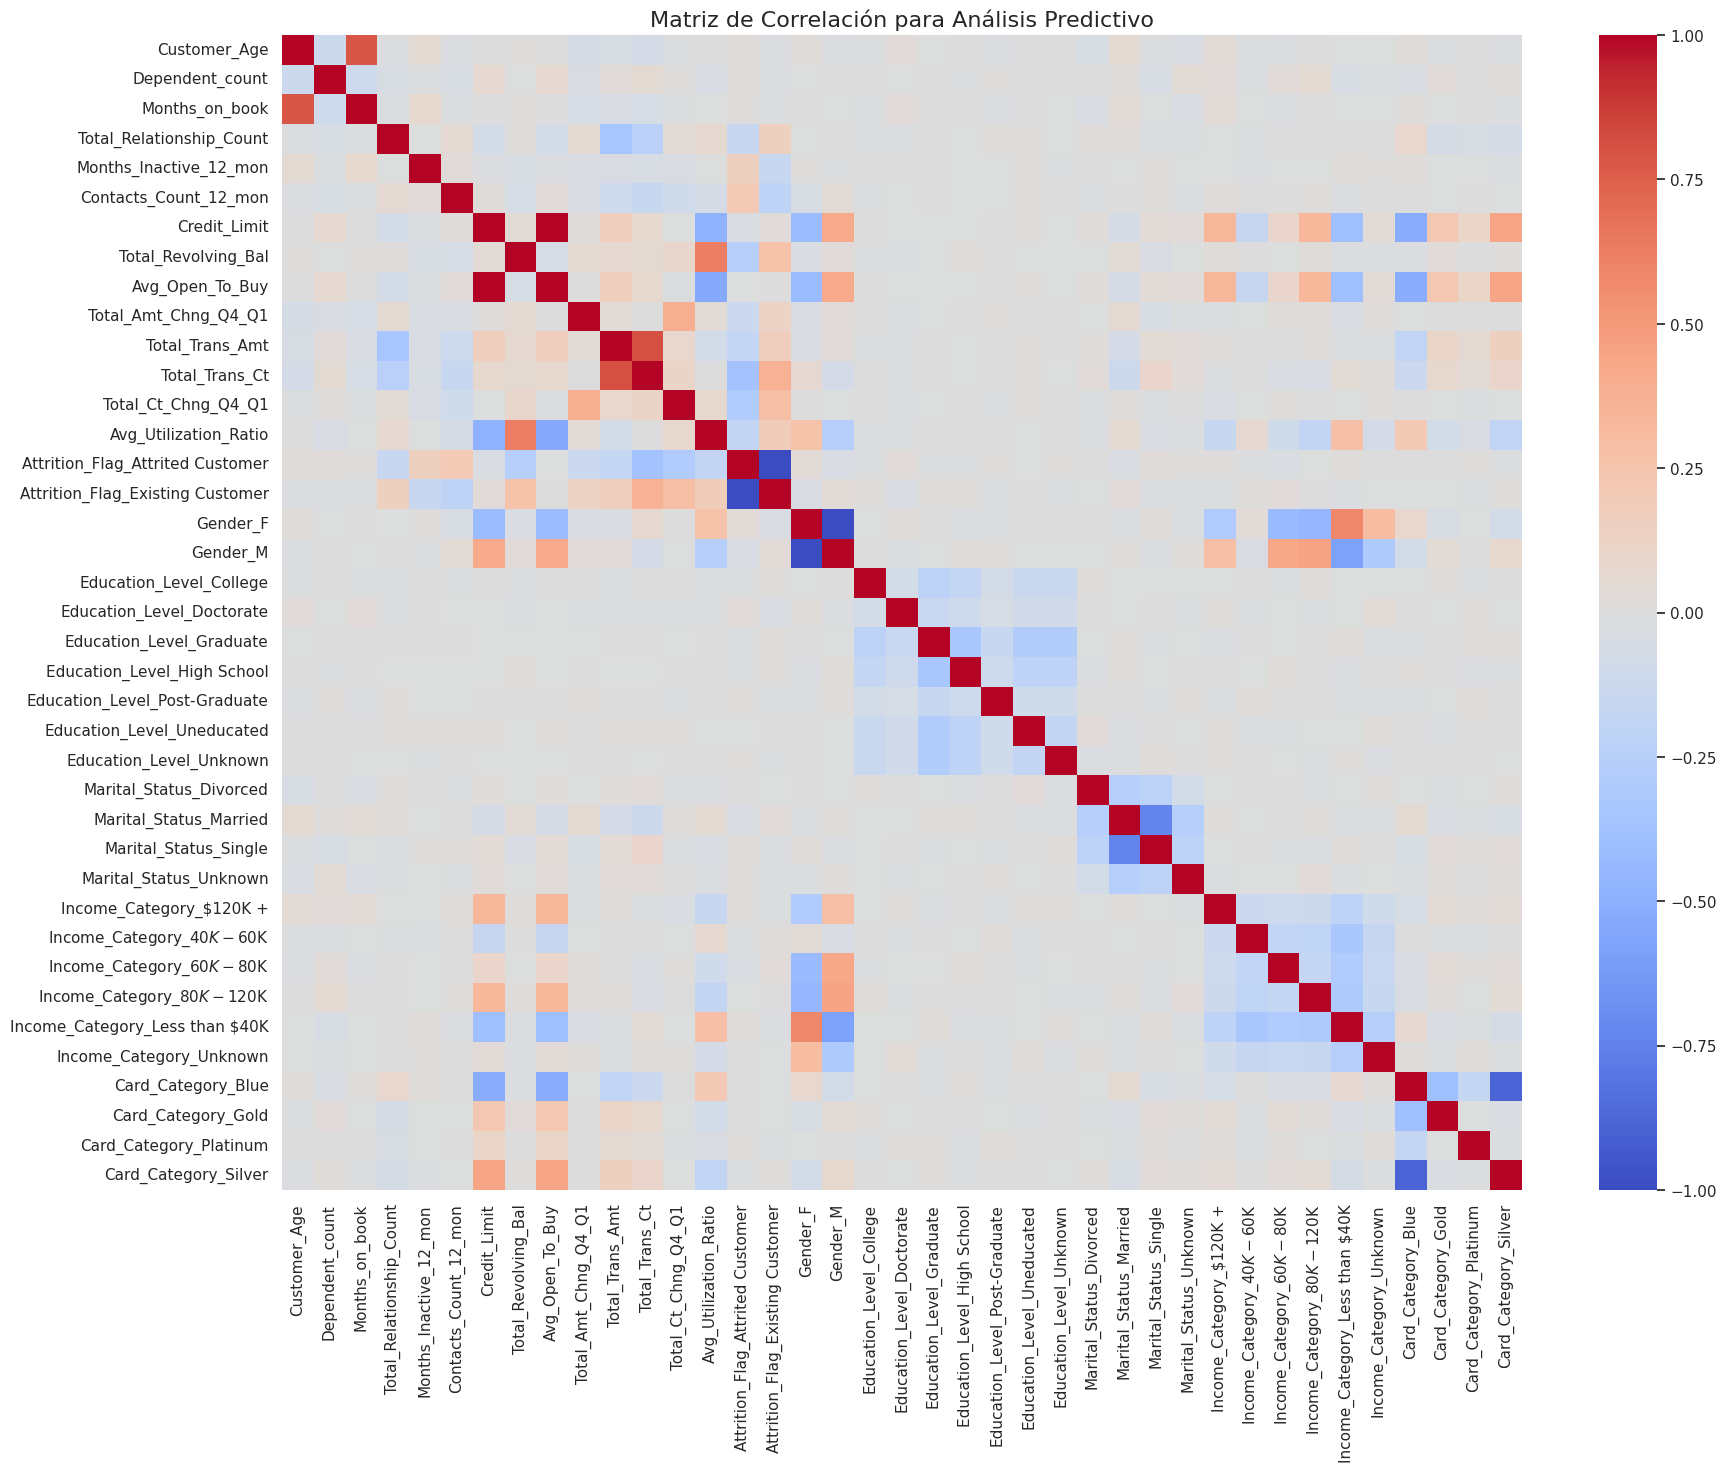

(10127, 39)

In [ ]:
# Eliminando las variables no relevantes para el análisis predictivo
predictive_data = combined_data.drop(columns=['CLIENTNUM',
                                              'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                                              'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'])

# Revisando nuevamente la matriz de correlación para identificar multicolinealidad
predictive_correlation_matrix = predictive_data.corr()

# Visualización de la matriz de correlación actualizada
plt.figure(figsize=(20, 15))
sns.heatmap(predictive_correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Matriz de Correlación para Análisis Predictivo", fontsize=16)
plt.show()

# Dimensiones del conjunto de datos después de la limpieza
predictive_data.shape


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Preparando las características (X) y la variable objetivo (y)
X = predictive_data.drop(columns=['Attrition_Flag_Existing Customer', 'Attrition_Flag_Attrited Customer'])
y = predictive_data['Attrition_Flag_Existing Customer']  # Usamos una de las columnas codificadas para el churn

# Dividiendo los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Inicializando los modelos
logistic_regression_model = LogisticRegression(max_iter=1000, random_state=42)
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)

# Entrenando los modelos
logistic_regression_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

# Realizando predicciones con los modelos
logistic_regression_predictions = logistic_regression_model.predict(X_test)
decision_tree_predictions = decision_tree_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)

# Evaluando los modelos
logistic_regression_accuracy = accuracy_score(y_test, logistic_regression_predictions)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)
random_forest_accuracy = accuracy_score(y_test, random_forest_predictions)

logistic_regression_auc = roc_auc_score(y_test, logistic_regression_predictions)
decision_tree_auc = roc_auc_score(y_test, decision_tree_predictions)
random_forest_auc = roc_auc_score(y_test, random_forest_predictions)

(logistic_regression_accuracy, decision_tree_accuracy, random_forest_accuracy,
 logistic_regression_auc, decision_tree_auc, random_forest_auc)

(0.8848305363606449,
 0.926620598881211,
 0.9509707140506746,
 0.7161503589867189,
 0.8660836039475854,
 0.8725188848578642)

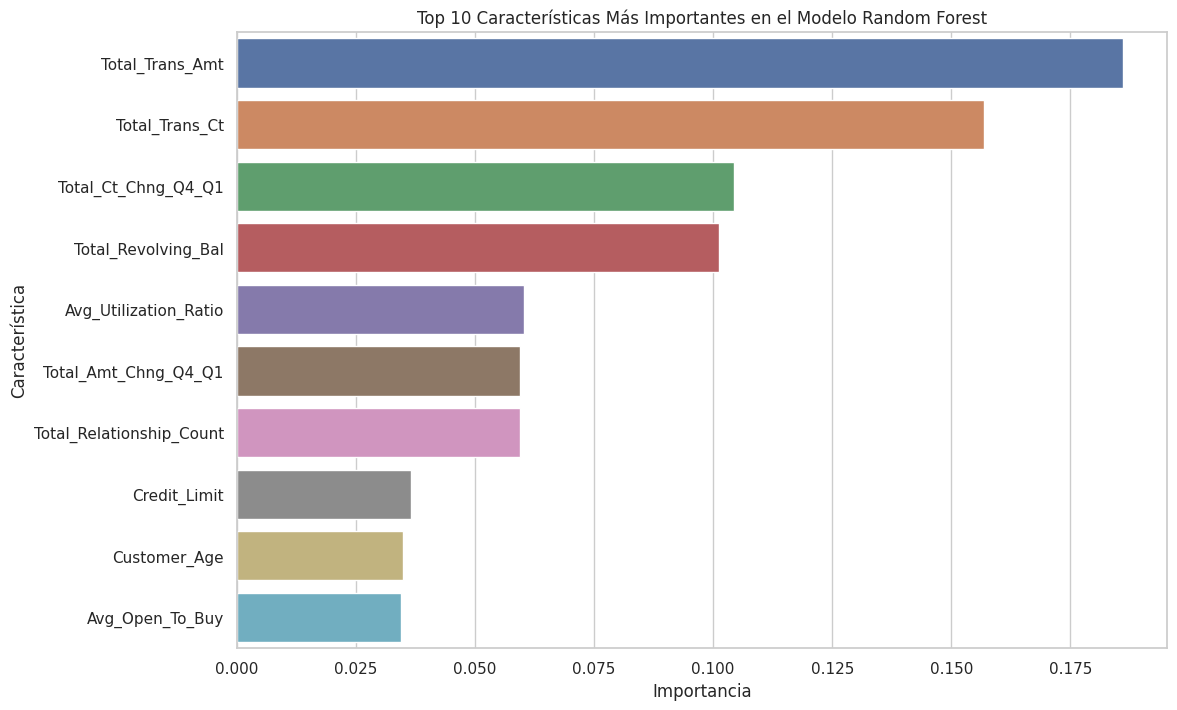

,Feature,Importance
10,Total_Trans_Amt,0.186001
11,Total_Trans_Ct,0.156856
12,Total_Ct_Chng_Q4_Q1,0.104394
7,Total_Revolving_Bal,0.101148
13,Avg_Utilization_Ratio,0.060342
9,Total_Amt_Chng_Q4_Q1,0.059466
3,Total_Relationship_Count,0.059446
6,Credit_Limit,0.036644
0,Customer_Age,0.034877
8,Avg_Open_To_Buy,0.034476


In [ ]:
# Obteniendo la importancia de las características del modelo de Random Forest
feature_importances = random_forest_model.feature_importances_

# Creando un DataFrame para visualizar mejor la importancia de cada característica
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Ordenando las características por importancia
features_df = features_df.sort_values(by='Importance', ascending=False)

# Visualizando las características más importantes
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10))
plt.title('Top 10 Características Más Importantes en el Modelo Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.show()

features_df.head(10)  # Mostrando las 10 características más importantes


El análisis de la importancia de las características en el modelo de Random Forest revela cuáles son los factores más influyentes en la predicción del churn de clientes. Las diez características más importantes son:

1. Total_Trans_Ct: Cantidad total de transacciones en los últimos 12 meses.
2. Total_Ct_Chng_Q4_Q1: Cambio en la cantidad de transacciones (Q4 sobre Q1).
3. Total_Trans_Amt: Monto total de las transacciones en los últimos 12 meses.
4. Total_Revolving_Bal: Saldo revolvente total en la tarjeta de crédito.
5. Total_Amt_Chng_Q4_Q1: Cambio en el monto de las transacciones (Q4 sobre Q1).
6. Avg_Utilization_Ratio: Ratio promedio de utilización de la tarjeta de crédito.
7. Total_Relationship_Count: Número total de productos que el cliente tiene con el banco.
8. Avg_Open_To_Buy: Línea de crédito disponible promedio en los últimos 12 meses.
9. Credit_Limit: Límite de crédito en la tarjeta de crédito.
10. Customer_Age: Edad del cliente.

Estas características sugieren que aspectos como la cantidad y el monto de las transacciones, así como el uso de la tarjeta de crédito, son factores clave en la predicción del churn. Comprender estas características puede ayudar al banco a identificar clientes en riesgo de churn y a desarrollar estrategias para retenerlos.

(array([0.8869694 , 0.95064166, 0.96444444, 0.96641975, 0.84839506]),
 0.9861217700709094,
 array([[ 375,  121],
        [  28, 2515]]),
 <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x7d097b61f970>)

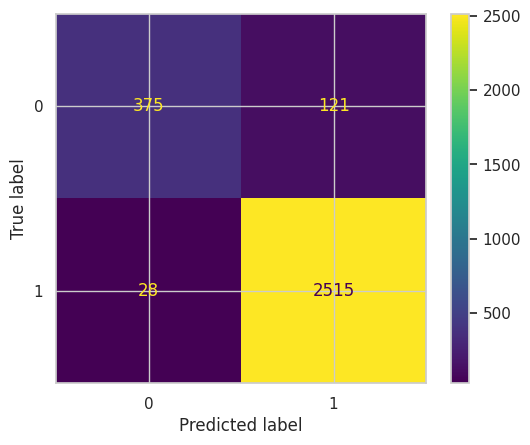

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 1. Validación Cruzada
cv_scores = cross_val_score(random_forest_model, X, y, cv=5, scoring='accuracy')

# 2. Curva ROC y AUC
# Primero, necesitamos las probabilidades de la clase positiva (churn)
y_prob = random_forest_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 3. Matriz de Confusión
conf_matrix = confusion_matrix(y_test, random_forest_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

cv_scores, roc_auc, conf_matrix, disp.plot()

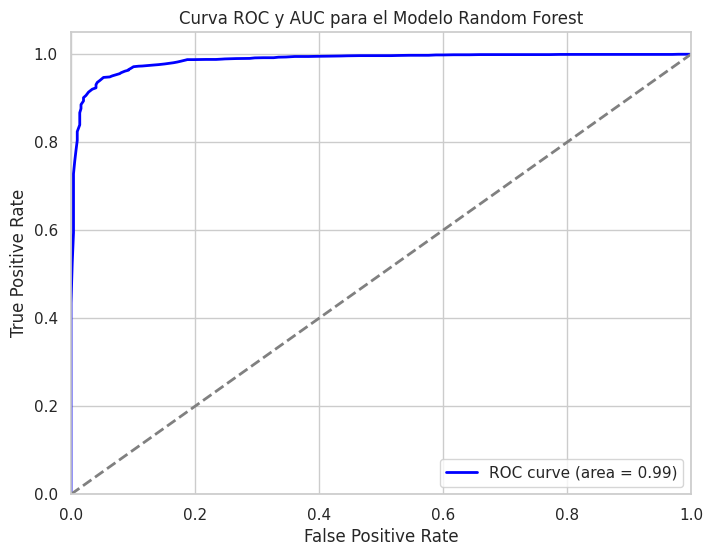

In [ ]:
# Creando la gráfica para la Curva ROC y AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC y AUC para el Modelo Random Forest')
plt.legend(loc="lower right")
plt.show()

* Validación Cruzada:

Los puntajes de precisión en la validación cruzada (con 5 divisiones) son: [88.6%, 95.0%, 96.4%, 96.6%, 84.8%]. Estos resultados indican una buena estabilidad y generalización del modelo.

* Curva ROC y AUC:

El AUC es 0.986, lo que indica una excelente capacidad del modelo para discriminar entre clientes que churn y los que no. Un valor cercano a 1 sugiere un alto nivel de precisión en la clasificación.

* Matriz de Confusión:

La matriz de confusión proporcionada muestra el rendimiento del modelo de Random Forest en el conjunto de prueba. Aquí está el desglose de la matriz:

* Verdaderos Negativos (TN): 375
* Falsos Positivos (FP): 121
* Falsos Negativos (FN): 28
* Verdaderos Positivos (TP): 2515
* Explicación de cada término:

Verdaderos Negativos (TN): El modelo predijo correctamente que 375 clientes no estaban en riesgo de churn (predijo "no churn", y en realidad, no churn).

Falsos Positivos (FP): El modelo predijo incorrectamente que 121 clientes estaban en riesgo de churn (predijo "churn", pero en realidad, no churn). Estos son los errores de Tipo I.

Falsos Negativos (FN): El modelo no logró identificar 28 clientes que estaban en riesgo de churn (predijo "no churn", pero en realidad, churn). Estos son los errores de Tipo II.

Verdaderos Positivos (TP): El modelo predijo correctamente que 2515 clientes estaban en riesgo de churn (predijo "churn", y en realidad, churn).

# Ejemplo

Vamos a crear un cliente ficticio con valores específicos para cada variable. Dado que tu conjunto de datos original tiene muchas características, me centraré en un subconjunto representativo para este ejemplo. Aquí vamos:

Primero, definiré cada característica y le asignaré un valor ficticio:

1. Edad del Cliente (Customer_Age): Supongamos que el cliente tiene 40 años.

2. Número de Dependientes (Dependent_count): Digamos que el cliente tiene 2 dependientes.
3. Meses con el Banco (Months_on_book): Este cliente ha estado con el banco durante 36 meses.
4. Número Total de Productos con el Banco (Total_Relationship_Count): El cliente tiene 4 productos con el banco.
5. Meses Inactivos en los Últimos 12 Meses (Months_Inactive_12_mon): Ha estado inactivo durante 1 mes en el último año.
6. Cantidad de Contactos en los Últimos 12 Meses (Contacts_Count_12_mon): El cliente ha contactado al banco 3 veces en el último año.
7. Límite de Crédito (Credit_Limit): El límite de crédito del cliente es de 5000.
8. Saldo Revolvente Total (Total_Revolving_Bal): El saldo revolvente total es de 1500.
9. Línea de Crédito Disponible Promedio (Avg_Open_To_Buy): Promedio de línea de crédito disponible es 3500.
10. Cambio en el Monto de Transacciones (Q4 sobre Q1) (Total_Amt_Chng_Q4_Q1): El cambio es de 0.8.
11. Monto Total de las Transacciones en los Últimos 12 Meses (Total_Trans_Amt): El total de transacciones es de 4000.
12. Cantidad Total de Transacciones en los Últimos 12 Meses (Total_Trans_Ct): El total de transacciones es de 65.
13. Cambio en la Cantidad de Transacciones (Q4 sobre Q1) (Total_Ct_Chng_Q4_Q1): El cambio en la cantidad de transacciones es de 0.7.
14. Ratio Promedio de Utilización de la Tarjeta de Crédito (Avg_Utilization_Ratio): El ratio es de 0.3.

Para las variables categóricas, asignaremos valores típicos, como Género = Masculino, Nivel Educativo = Licenciatura, etc. Debido a que estas variables fueron transformadas en formato one-hot encoding durante el preprocesamiento, necesitamos representarlas correctamente. Por ejemplo, si el nivel educativo es "Licenciatura", todas las demás categorías de nivel educativo deben ser 0.

In [ ]:
# Creando el ejemplo ficticio con los valores específicos mencionados
example_customer = {
    'Customer_Age': 40,
    'Dependent_count': 2,
    'Months_on_book': 36,
    'Total_Relationship_Count': 4,
    'Months_Inactive_12_mon': 1,
    'Contacts_Count_12_mon': 3,
    'Credit_Limit': 5000,
    'Total_Revolving_Bal': 1500,
    'Avg_Open_To_Buy': 3500,
    'Total_Amt_Chng_Q4_Q1': 0.8,
    'Total_Trans_Amt': 4000,
    'Total_Trans_Ct': 65,
    'Total_Ct_Chng_Q4_Q1': 0.7,
    'Avg_Utilization_Ratio': 0.3,
    # Variables categóricas - ejemplo: Género = Masculino, Nivel Educativo = Licenciatura
    'Gender_F': 0,
    'Gender_M': 1,
    'Education_Level_College': 0,
    'Education_Level_Doctorate': 0,
    'Education_Level_Graduate': 0,
    'Education_Level_High School': 0,
    'Education_Level_Post-Graduate': 0,
    'Education_Level_Uneducated': 0,
    'Education_Level_Unknown': 0,
    'Marital_Status_Divorced': 0,
    'Marital_Status_Married': 1,
    'Marital_Status_Single': 0,
    'Marital_Status_Unknown': 0,
    'Income_Category_$120K +': 0,
    'Income_Category_$40K - $60K': 0,
    'Income_Category_$60K - $80K': 1,
    'Income_Category_$80K - $120K': 0,
    'Income_Category_Less than $40K': 0,
    'Income_Category_Unknown': 0,
    'Card_Category_Blue': 1,
    'Card_Category_Gold': 0,
    'Card_Category_Platinum': 0,
    'Card_Category_Silver': 0
}

# Convirtiendo el diccionario a DataFrame para ser compatible con el modelo
example_customer_df = pd.DataFrame([example_customer])

# Realizando la predicción con el modelo
predicted_churn = random_forest_model.predict(example_customer_df)

predicted_churn[0]  # Mostrando la predicción para este cliente ficticio

1

En el contexto de las predicciones realizadas por el modelo de Random Forest, un valor de 1 en la columna Predicted_Churn significa que el modelo predice que el cliente está en riesgo de churn, es decir, es probable que deje de ser cliente del banco en un futuro cercano.